In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Read the CSV file
df = pd.read_csv(r'spams.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [11]:
df['text_length']=df['text'].apply(len)
df['num_words']=df['text'].apply(lambda x:len(x.split()))
df['num_digits']=df['text'].apply(lambda x:sum(c.isdigit() for c in x))

X=df[['text_length','num_words','num_digits']]
y=df['label']




In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [15]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()

In [18]:
gnb.fit(X_train_scaled,y_train)
y_pred_gnb=gnb.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay

accuracy_score =  0.9802690582959641


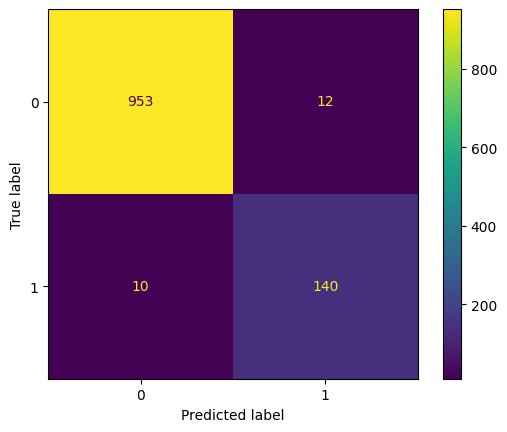

In [31]:
print('accuracy_score = ',accuracy_score(y_test,y_pred_gnb))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gnb
)

# Multinomial Naive bayess

In [29]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
vectorizer=CountVectorizer(stop_words='english')
x_counts=vectorizer.fit_transform(df['text'])

tfidf_transform=TfidfTransformer()
X_tfidf=tfidf_transform.fit_transform(x_counts)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.2, random_state=42
)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

accuracy_score =  0.968609865470852


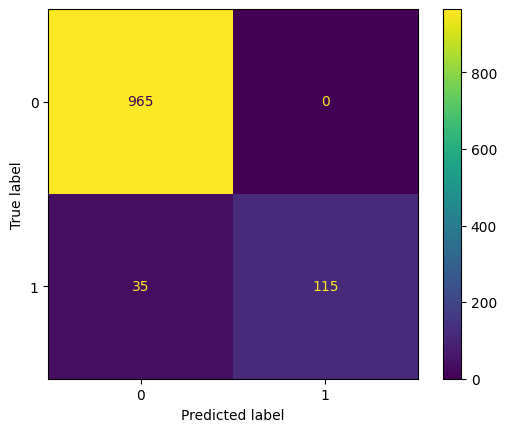

In [30]:
print('accuracy_score = ',accuracy_score(y_test,y_pred_mnb))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mnb
)

In [24]:
from sklearn.naive_bayes import BernoulliNB
imp_words=['free','win','offer','money','urgent']
for word in imp_words:
    df[word]=df['text'].apply(lambda x:1 if word in x.lower() else 0)

X=df[imp_words]
y=df['label']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

bnb=BernoulliNB()
bnb.fit(X_train,y_train)
y_pred_bnb=bnb.predict(X_test)

In [25]:
print('accuracy_score = ',accuracy_score(y_test,y_pred_bnb))

accuracy_score =  0.895067264573991


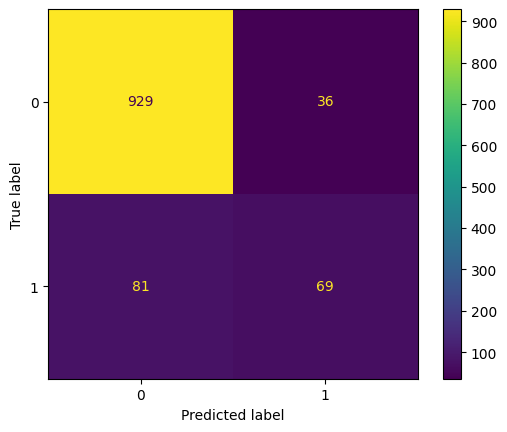

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bnb
)